# Perceptrón de Hinton
### Descripción General del Práctico
En este práctico, exploraremos la implementación y el entrenamiento de un modelo Perdeptrón de Hinton para generación de imágenes. Usaremos los datasets [MNIST](https://es.wikipedia.org/wiki/Base_de_datos_MNIST) y [FashionMNIST](https://en.wikipedia.org/wiki/Fashion_MNIST).

### Objetivo del Práctico
El objetivo de este práctico es endender cómo se implementa y entrena el Perceptrón presentado por Hinton para generación de imágenes.

### Imports

In [1]:
import time
import math
import torch
import random
import matplotlib.pyplot as plt
import torch.nn as nn
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data.dataloader import DataLoader
from tqdm import tqdm

### Seteo de Device

Seteamos sobre que dispositivo vamos a estar corriendo el entrenamiento e inferencia.

In [2]:
DEVICE = torch.device(
    'cuda:0' if torch.cuda.is_available() else 
    'mps' if torch.backends.mps.is_available() else 
    'cpu'
)
print(DEVICE)

torch.manual_seed(42)
torch.backends.cudnn.deterministic = True

cuda:0


### Transformaciones:

Creamos la transformación para binarizar nuestro dataset. Esto va a hacer que pasemos de $[0, 256]$ a $\{0, 1\}$. A su vez agregamos la transformación trabajar con tensores.

In [3]:
class BinarizedTransform:
    def __call__(self, img):
        return (img > .5).float()
    
img_transforms = transforms.Compose([transforms.ToTensor(), BinarizedTransform()])
img_shape = (28,28)
img_size = 28*28*1
num_classes = 10

### Dataset

Vamos a estar trabajando con el dataset de [MNIST](https://es.wikipedia.org/wiki/Base_de_datos_MNIST) que nos brinda imágenes de 28*28 de dígitos escritos a mano.

Para la generación vamos a estar trabajando únicamente con un solo dígito. Vamos a setearlo en este momento y continuamos trabajando con este.

In [4]:
labels_used = [1]

### Carga de datos y creación de Dataloader.

In [5]:
BATCH_SIZE = 64

download_dataset = True

train_data = datasets.MNIST(root='mnist/', train=True, transform=img_transforms, download=download_dataset)
train_data = [(image, label) for image, label in train_data if labels_used and label in labels_used]

train_dataloader = DataLoader(
    train_data, batch_size=BATCH_SIZE, shuffle=True
)

### Exploración del Dataset

In [6]:
def show_images(images, title="MNIST Images"):
    n = len(images)
    rows = math.floor(math.sqrt(n))
    columns = math.ceil(n / rows)

    fig, axs = plt.subplots(rows, columns)
    fig.suptitle(title, fontsize=14, y=.95)

    for i in range(rows):
        for j in range(columns):
            index = i*columns + j
            if index < n:
                axs[i,j].imshow(images[index], cmap='gray')
            axs[i,j].axis('off')

    plt.show()

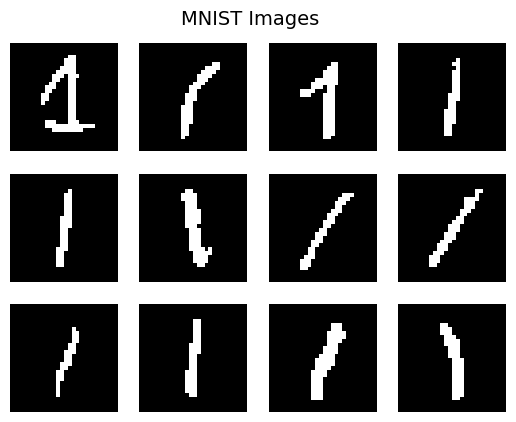

In [7]:
images = []
for _ in range(12):
    image, label = train_data[random.randrange(len(train_data))]
    images.append(image.reshape(img_shape))
show_images(images)

### Definicion de Hinton Perceptron

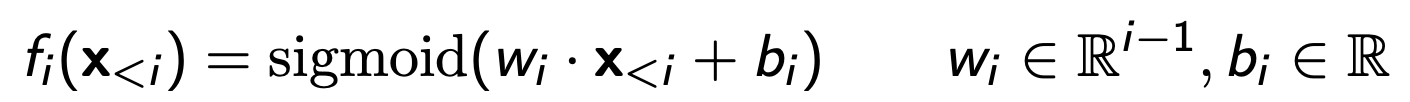

Para replicar esto usaremos una máscara que deje a todos los pesos que "ven el futuro" no afecten la predicción.
Revisar [torch.tril](https://docs.pytorch.org/docs/stable/generated/torch.tril.html). No se olviden de la diagonal!

In [8]:
ones = torch.ones((3,3))

masked_ones = torch.tril(ones, diagonal=-1)
print(masked_ones.T)
print(torch.matmul(ones, masked_ones.T))

tensor([[0., 1., 1.],
        [0., 0., 1.],
        [0., 0., 0.]])
tensor([[0., 1., 2.],
        [0., 1., 2.],
        [0., 1., 2.]])


¿Qué resultado debería dara la multiplicación de ones . masked_ones.T?

**Respuesta:**

Debería dar una matriz triangular inferior con valores acumulados. Cada fila suma los elementos de la columna correspondiente que están por debajo de la diagonal.

Recomendamos usar [nn.Parameter](https://docs.pytorch.org/docs/stable/generated/torch.nn.parameter.Parameter.html) para la definición de los pesos y del bias.

In [9]:
class HintonPerceptron(nn.Module):
    def __init__(
        self,
        input_size: int,
        img_shape: tuple[int, int]
    ):
        super(HintonPerceptron, self).__init__()
        self.img_shape = img_shape
        self.img_size = torch.prod(torch.tensor(img_shape)).item()

        self.w = nn.Parameter(torch.randn(self.img_size, self.img_size) * 0.01)

        self.mask = torch.tril(torch.ones((self.img_size, self.img_size)), diagonal=-1)

        self.bias = nn.Parameter(torch.zeros(self.img_size))
        
    def forward(
        self,
        x: torch.Tensor
    ):
        w_masked = self.w * self.mask.to(x.device)

        x_w = torch.matmul(x, w_masked.T)

        logits = x_w + self.bias
        
        return torch.sigmoid(logits)
    
    def generate_x(
        self,
        num_images: int
    ):
        with torch.no_grad():
            x = torch.zeros(num_images, self.img_size).to(self.w.device)
            
            for pixel in range(self.img_size):
                probs = self.forward(x)
                x[:, pixel] = torch.bernoulli(probs[:, pixel])
            
            return x.view(-1, *self.img_shape)

### Creación del modelo y seteo de Hyper-parámetros
En esta sección del código, se crea el modelo.

Y se eligen arbitrariamente los siguientes hyper-parámetros:
- learning rate (lr)
- cantidad de épocas (epochs)
- optimizador (optim)

In [10]:
lr = 0.001
epochs = 100
criterion = nn.BCELoss()

model = HintonPerceptron(
    input_size=img_size,
    img_shape=img_shape
).to(DEVICE)

optim = torch.optim.Adam(model.parameters(), lr=lr)

¿Por qué eligió usar esa función de pérdida?

**Respuesta:**

BCELoss es apropiada porque cada píxel es binario y estamos estimando probabilidades con Bernoulli.

### Proceso de entrenamiento del modelo
En esta celda, se define el entrenamiento del modelo utilizando un conjunto de datos de entrenamiento.

El código optimiza los parámetros del modelo minimizando la función de pérdida previamente definida a través de un optimizador.

In [11]:
def train_model(
    model: nn.Module,
    criterion: nn.Module,
    n_epochs: int,
    train_loader: DataLoader,
    optim: torch.optim.Optimizer,
    print_epoch: int = 1
):
    for epoch in tqdm(range(n_epochs)):
        start_time = time.time()
        learning_error = 0
        for img, _ in train_loader:
            x = img.view(img.size(0), -1).to(DEVICE)
    
            optim.zero_grad()

            preds = model(x)

            loss = criterion(preds, x)

            loss.backward()

            optim.step()

            learning_error += loss.item()

        if epoch%print_epoch == 0:
            imgs = model.generate_x(12).cpu()
            show_images(imgs, f"Generated images on epoch {epoch+1}")
            print(f"Epoch: {epoch+1} - duration {time.time()-start_time}s- error: {learning_error/len(train_loader)}")

    return model

¿Por qué no usamos los valores de `y` que tiene el dataset? ¿No nos afecta esto al calcular la loss?

**Respuesta:**

No usamos las labels porque estamos entrenando un modelo generativo. La loss compara cada píxel predicho con el píxel real de la misma imagen, no con una etiqueta de clase.

### Entrenamos el modelo!

  0%|          | 0/100 [00:00<?, ?it/s]

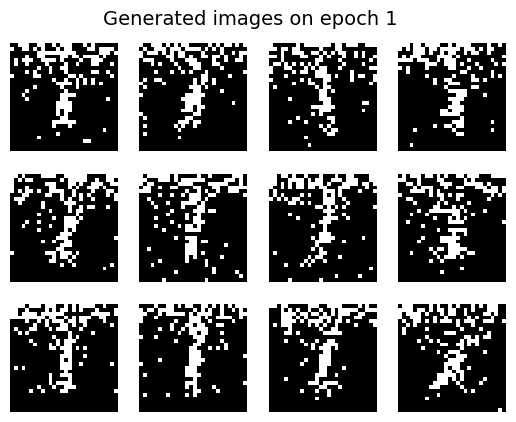

  2%|▏         | 2/100 [00:00<00:29,  3.34it/s]

Epoch: 1 - duration 0.55238938331604s- error: 0.40317615669853285


 20%|██        | 20/100 [00:02<00:09,  8.34it/s]

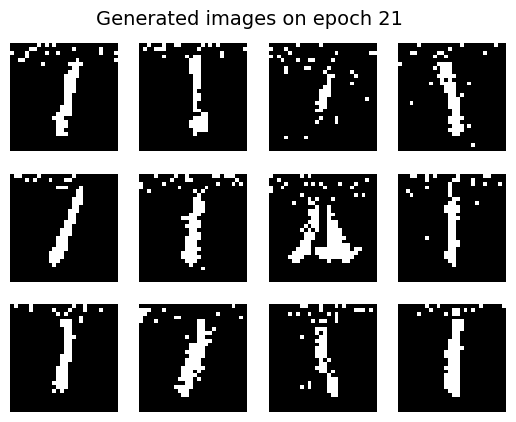

 22%|██▏       | 22/100 [00:03<00:14,  5.34it/s]

Epoch: 21 - duration 0.4330136775970459s- error: 0.07737917382762118


 40%|████      | 40/100 [00:05<00:07,  8.32it/s]

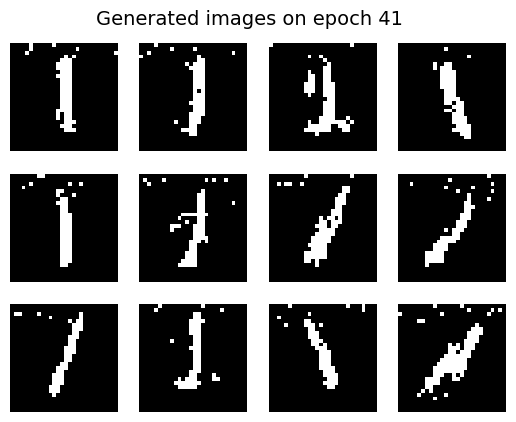

 42%|████▏     | 42/100 [00:06<00:10,  5.28it/s]

Epoch: 41 - duration 0.45226383209228516s- error: 0.04995538262685515


 60%|██████    | 60/100 [00:08<00:04,  8.28it/s]

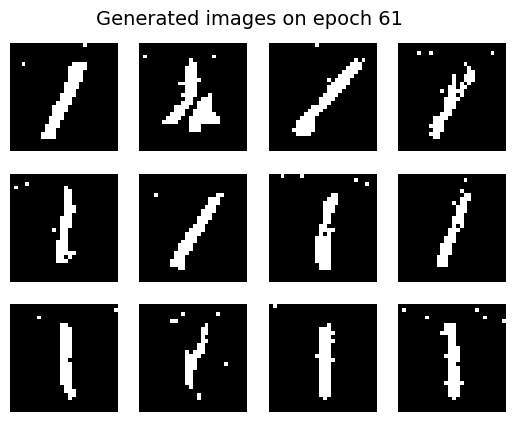

 62%|██████▏   | 62/100 [00:08<00:07,  5.33it/s]

Epoch: 61 - duration 0.43787169456481934s- error: 0.04075262164872772


 80%|████████  | 80/100 [00:11<00:02,  8.32it/s]

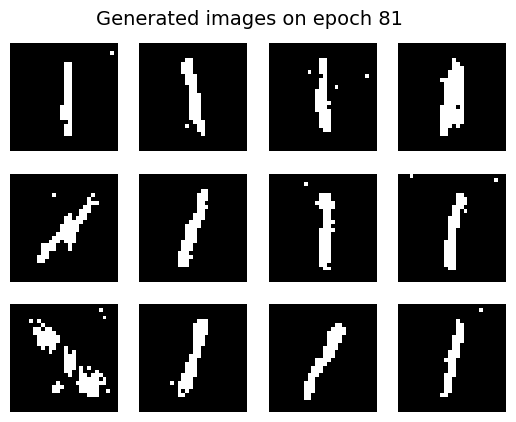

 82%|████████▏ | 82/100 [00:11<00:03,  4.86it/s]

Epoch: 81 - duration 0.5231678485870361s- error: 0.036862374406378226


100%|██████████| 100/100 [00:13<00:00,  7.21it/s]


In [12]:
trained_model = train_model(
    model=model,
    criterion=criterion,
    n_epochs=int(epochs),
    train_loader=train_dataloader,
    optim=optim,
    print_epoch=20
)

### Probamos el modelo generando imagenes

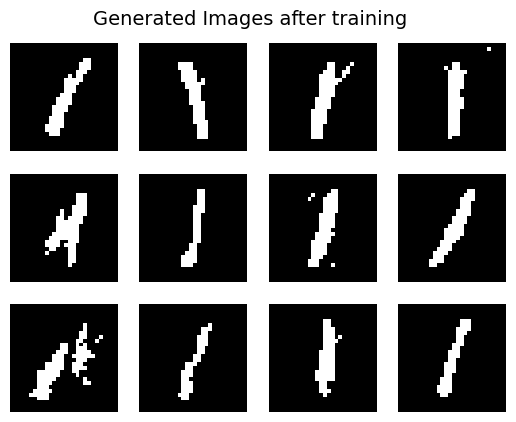

In [13]:
imgs = model.generate_x(12).cpu()
show_images(imgs, "Generated Images after training")

## Ejercicios:
1) Complete el código del perceptrón de Hinton.
2) Entrene el modelo utilizando 1 dígito.
3) Entrene el modelo utilizando al menos 3 dígitos.
4) Compare resultados. ¿Qué diferencias observas?
5) Entrene el modelo con el dataset de [FashionMNIST](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html).
6) Compare y comente sobre los resultados obtenidos.

---
# CONFIGURACIÓN 2: MNIST con 3 dígitos [1, 3, 5]

In [14]:
labels_used = [1, 3, 5]

train_data = datasets.MNIST(root='mnist/', train=True, transform=img_transforms, download=False)
train_data = [(image, label) for image, label in train_data if labels_used and label in labels_used]

train_dataloader = DataLoader(
    train_data, batch_size=BATCH_SIZE, shuffle=True
)

print(f"Datos cargados: {len(train_data)} imágenes con dígitos {labels_used}")

Datos cargados: 18294 imágenes con dígitos [1, 3, 5]


In [15]:
model_3digits = HintonPerceptron(
    input_size=img_size,
    img_shape=img_shape
).to(DEVICE)

optim_3digits = torch.optim.Adam(model_3digits.parameters(), lr=lr)

print("Modelo reinicializado para 3 dígitos")

Modelo reinicializado para 3 dígitos


  0%|          | 0/100 [00:00<?, ?it/s]

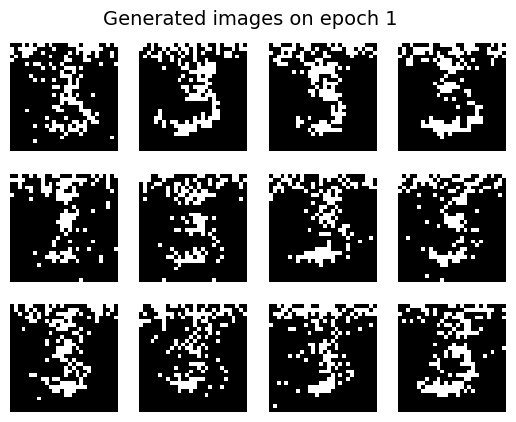

  1%|          | 1/100 [00:00<01:11,  1.38it/s]

Epoch: 1 - duration 0.7260184288024902s- error: 0.34921922748322254


 20%|██        | 20/100 [00:06<00:27,  2.96it/s]

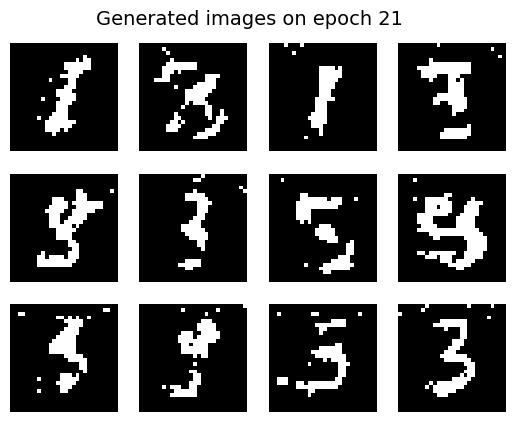

 21%|██        | 21/100 [00:07<00:34,  2.32it/s]

Epoch: 21 - duration 0.6481809616088867s- error: 0.08982884990689638


 40%|████      | 40/100 [00:14<00:20,  2.92it/s]

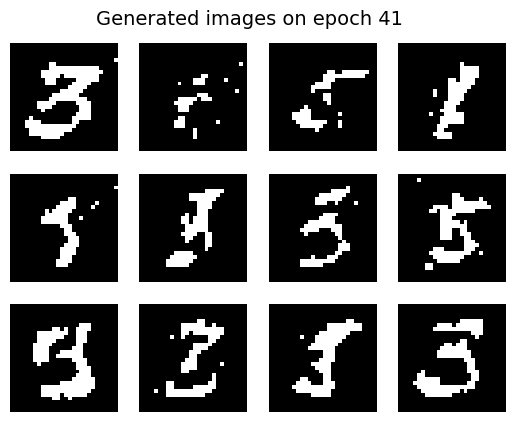

 41%|████      | 41/100 [00:14<00:25,  2.31it/s]

Epoch: 41 - duration 0.6423356533050537s- error: 0.07887683188790208


 60%|██████    | 60/100 [00:20<00:12,  3.08it/s]

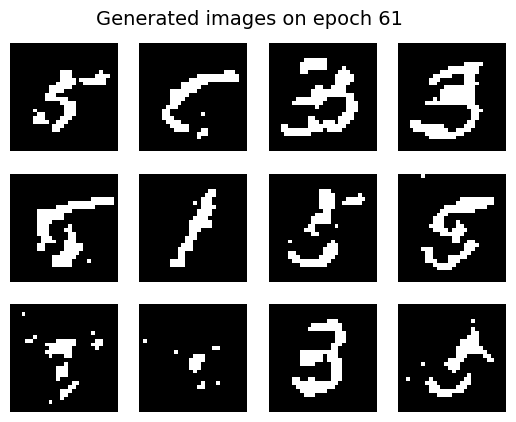

 61%|██████    | 61/100 [00:21<00:16,  2.39it/s]

Epoch: 61 - duration 0.636378288269043s- error: 0.07649188579900282


 80%|████████  | 80/100 [00:27<00:06,  2.96it/s]

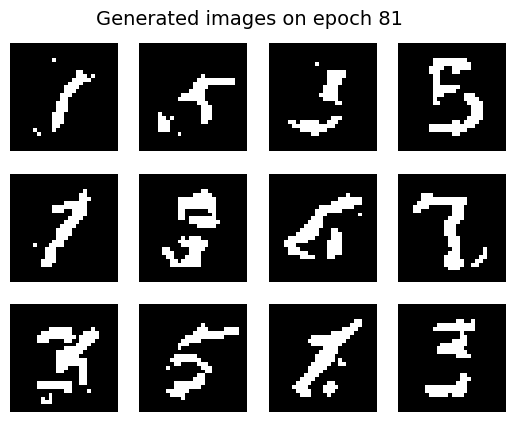

 81%|████████  | 81/100 [00:28<00:08,  2.31it/s]

Epoch: 81 - duration 0.6543476581573486s- error: 0.07552230959901443


100%|██████████| 100/100 [00:34<00:00,  2.88it/s]


In [16]:
trained_model_3digits = train_model(
    model=model_3digits,
    criterion=criterion,
    n_epochs=int(epochs),
    train_loader=train_dataloader,
    optim=optim_3digits,
    print_epoch=20
)

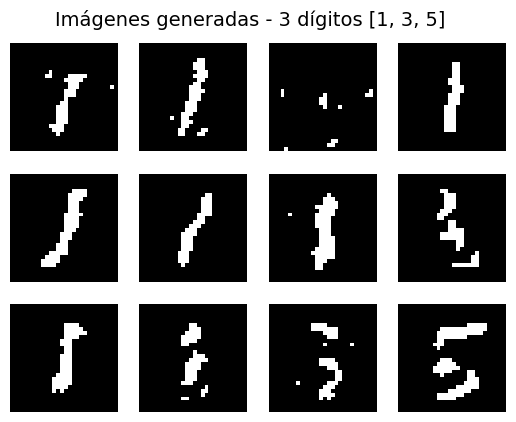

In [17]:
imgs_3digits = trained_model_3digits.generate_x(12).cpu()
show_images(imgs_3digits, "Imágenes generadas - 3 dígitos [1, 3, 5]")

### Ejercicio 4: Comparación 1 dígito vs 3 dígitos

**Error final (3 dígitos)**: (ver último epoch arriba)

**Observaciones**:
- Los 3 dígitos aparecen en las imágenes generadas, principalmente 1s y 3s, con algunos 5s
- La calidad es más baja que con 1 dígito: las imágenes son más ruidosas y fragmentadas
- Hay algunas imágenes con ruido o píxeles sueltos que no forman dígitos claros
- El modelo aprende múltiples patrones pero con menor nitidez en cada uno

---
# CONFIGURACIÓN 3: FashionMNIST - T-shirts (Clase 0)

In [18]:
labels_used = [0]

train_data = datasets.FashionMNIST(root='fashion_mnist/', train=True, transform=img_transforms, download=True)
train_data = [(image, label) for image, label in train_data if labels_used and label in labels_used]

train_dataloader = DataLoader(
    train_data, batch_size=BATCH_SIZE, shuffle=True
)

print(f"Datos cargados: {len(train_data)} imágenes de FashionMNIST - Clase 0 (T-shirt/top)")

Datos cargados: 6000 imágenes de FashionMNIST - Clase 0 (T-shirt/top)


Modelo reinicializado para FashionMNIST


  0%|          | 0/100 [00:00<?, ?it/s]

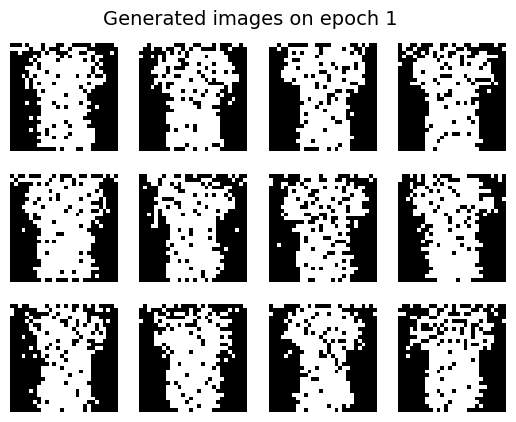

  2%|▏         | 2/100 [00:00<00:23,  4.12it/s]

Epoch: 1 - duration 0.4306070804595947s- error: 0.4067942030886386


 20%|██        | 20/100 [00:02<00:08,  9.24it/s]

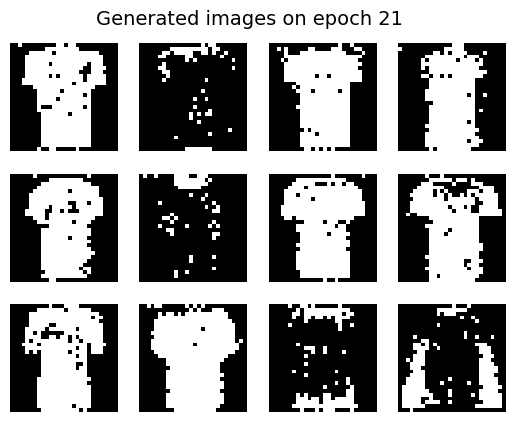

 22%|██▏       | 22/100 [00:02<00:13,  5.93it/s]

Epoch: 21 - duration 0.4401693344116211s- error: 0.15717632814924767


 40%|████      | 40/100 [00:05<00:07,  7.61it/s]

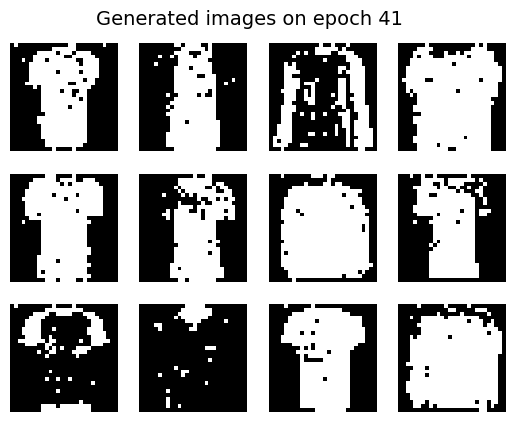

 42%|████▏     | 42/100 [00:05<00:11,  5.12it/s]

Epoch: 41 - duration 0.4639699459075928s- error: 0.1285611185780231


 60%|██████    | 60/100 [00:07<00:04,  8.84it/s]

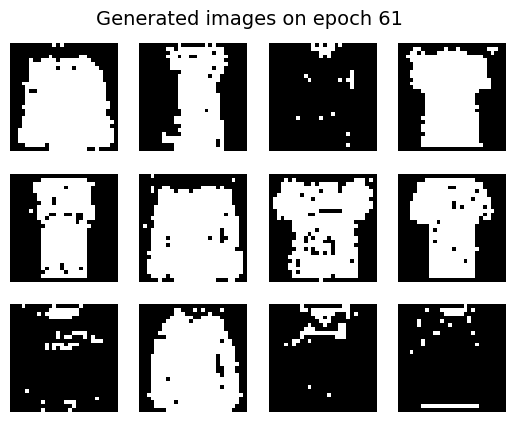

 62%|██████▏   | 62/100 [00:08<00:07,  5.14it/s]

Epoch: 61 - duration 0.5044658184051514s- error: 0.11653452699488782


 80%|████████  | 80/100 [00:11<00:03,  5.34it/s]

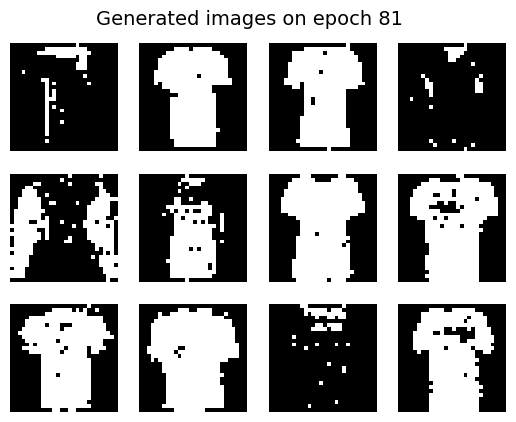

 82%|████████▏ | 82/100 [00:12<00:05,  3.38it/s]

Epoch: 81 - duration 0.7143692970275879s- error: 0.11050765668141081


100%|██████████| 100/100 [00:15<00:00,  6.36it/s]


In [19]:
model_fashion = HintonPerceptron(
    input_size=img_size,
    img_shape=img_shape
).to(DEVICE)

optim_fashion = torch.optim.Adam(model_fashion.parameters(), lr=lr)

print("Modelo reinicializado para FashionMNIST")

trained_model_fashion = train_model(
    model=model_fashion,
    criterion=criterion,
    n_epochs=int(epochs),
    train_loader=train_dataloader,
    optim=optim_fashion,
    print_epoch=20
)

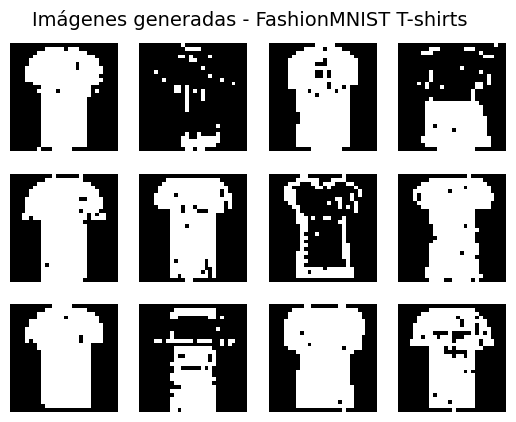

In [22]:
imgs_fashion = trained_model_fashion.generate_x(12).cpu()
show_images(imgs_fashion, "Imágenes generadas - FashionMNIST T-shirts")

### Ejercicio 6: Comparación MNIST vs FashionMNIST

**Error final FashionMNIST**: (ver último epoch arriba)

**Observaciones**:
- Sí se reconocen siluetas de remeras (cuerpo y mangas)
- Calidad inferior a MNIST: más ruido, bordes irregulares, píxeles sueltos
- FashionMNIST es más difícil porque las prendas tienen formas más complejas y mayor variabilidad que los dígitos simples